In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import matplotlib.pyplot as plt
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

✓ Libraries imported successfully
pandas version: 2.3.3
numpy version: 2.3.5


In [2]:
# ==========================================
# LOAD DATA
# ==========================================

# Load the dataset
df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")

print("Original dataset:")
print(f"  Rows: {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")

# Create working copy
df_feat = df.copy()

# Ensure consistent types
df_feat["marks"] = pd.to_numeric(df_feat["marks"], errors="coerce")
df_feat["englishmarks_12"] = pd.to_numeric(df_feat["englishmarks_12"], errors="coerce")

# Clean college codes
df_feat["allotted_JC_code"] = (
    df_feat["allotted_JC_code"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\n✓ Data loaded and types standardized")

Original dataset:
  Rows: 39,435
  Columns: 278

✓ Data loaded and types standardized


In [3]:
# ==========================================
# FILTER: RESIDENTIAL COLLEGES ONLY
# ==========================================

# Keep only students with valid allotted college
df_feat = df_feat[df_feat["allotted_JC_code"].notna()]
df_feat = df_feat[df_feat["allotted_JC_code"] != ""]
df_feat = df_feat[~df_feat["allotted_JC_code"].isin(["nan", "none"])]

print("After residential-college filter:")
print(f"  Students remaining: {df_feat.shape[0]:,}")

# Check for missing outcome variable
n_missing_outcome = df_feat["englishmarks_12"].isna().sum()
print(f"  Missing englishmarks_12: {n_missing_outcome:,}")

# Keep only students with both marks and outcome
df_feat = df_feat[df_feat["marks"].notna() & df_feat["englishmarks_12"].notna()]

print(f"\nAfter removing missing marks/outcomes:")
print(f"  Students remaining: {df_feat.shape[0]:,}")

After residential-college filter:
  Students remaining: 6,414
  Missing englishmarks_12: 0

After removing missing marks/outcomes:
  Students remaining: 6,348


In [4]:
# ==========================================
# EXTRACT STREAM AND DESCRIPTIVE STATS
# ==========================================

# Extract stream from college code (last 3 characters)
df_feat["stream"] = df_feat["allotted_JC_code"].str[-3:]

print("STREAM DISTRIBUTION:")
print(df_feat["stream"].value_counts())

print("\nBASIC STATISTICS:")
print("\nEntrance Marks (marks):")
print(df_feat["marks"].describe())

print("\nOutcome (englishmarks_12):")
print(df_feat["englishmarks_12"].describe())

print("\nCorrelation (marks vs englishmarks_12):")
print(f"  r = {df_feat['marks'].corr(df_feat['englishmarks_12']):.3f}")

print("\nNumber of unique colleges:")
print(f"  {df_feat['allotted_JC_code'].nunique()}")

STREAM DISTRIBUTION:
stream
bpc    2696
mpc    2493
cec     692
mec     333
hec     134
Name: count, dtype: int64

BASIC STATISTICS:

Entrance Marks (marks):
count    6348.000000
mean       37.097944
std        18.122378
min        -5.000000
25%        23.937500
50%        35.000000
75%        47.500000
max       108.750000
Name: marks, dtype: float64

Outcome (englishmarks_12):
count    6348.000000
mean       77.503197
std        14.577905
min         5.000000
25%        69.000000
50%        81.000000
75%        90.000000
max        98.000000
Name: englishmarks_12, dtype: float64

Correlation (marks vs englishmarks_12):
  r = 0.407

Number of unique colleges:
  193


In [5]:
# ==========================================
# FEATURE ENGINEERING: STANDARDIZE MARKS
# ==========================================

# Standardize entrance marks (mean=0, std=1)
df_feat["marks_std"] = (
    df_feat["marks"] - df_feat["marks"].mean()
) / df_feat["marks"].std()

print("Standardized marks:")
print(df_feat["marks_std"].describe())
print("\n✓ Entrance marks standardized")

Standardized marks:
count    6.348000e+03
mean     1.343181e-17
std      1.000000e+00
min     -2.322981e+00
25%     -7.261985e-01
50%     -1.157654e-01
75%      5.739895e-01
max      3.953789e+00
Name: marks_std, dtype: float64

✓ Entrance marks standardized


In [6]:
# ==========================================
# FEATURE ENGINEERING: STREAM INDICATORS
# ==========================================

# One-hot encode stream
stream_dummies = pd.get_dummies(df_feat["stream"], prefix="stream")

print("Stream indicators created:")
print(f"  Shape: {stream_dummies.shape}")
print(f"  Columns: {list(stream_dummies.columns)}")
print("\n✓ Stream indicators created")

Stream indicators created:
  Shape: (6348, 5)
  Columns: ['stream_bpc', 'stream_cec', 'stream_hec', 'stream_mec', 'stream_mpc']

✓ Stream indicators created


In [7]:
# ==========================================
# FEATURE ENGINEERING: PREFERENCE ENCODING
# ==========================================

# Define preference columns
pref_cols = [
    "general_pref1", "general_pref2", "general_pref3", "general_pref4",
    "general_pref5", "general_pref6", "general_pref7", "general_pref8",
    "general_pref9", "general_pref10", "general_pref11", "general_pref12",
    "general_pref13", "general_pref14", "general_pref15", "general_pref16",
    "general_pref17", "general_pref18", "general_pref19", "general_pref20"
]

def encode_preferences(row, decay=0.8):
    """
    Encode preference rankings with exponential decay.
    Higher-ranked preferences get more weight.
    """
    vec = defaultdict(float)
    for i, col in enumerate(pref_cols):
        if col in row and pd.notnull(row[col]):
            vec[row[col]] += decay ** i
    return vec

# Apply to each student
pref_vectors = df_feat.apply(encode_preferences, axis=1)

# Convert to DataFrame - CRITICAL: Keep index aligned
pref_df = pd.DataFrame(pref_vectors.tolist(), index=df_feat.index).fillna(0)

print("Preference encoding:")
print(f"  Shape: {pref_df.shape}")
print(f"  Non-zero entries per student: {(pref_df > 0).sum(axis=1).describe()}")
print("\n✓ Preferences encoded with exponential decay")

Preference encoding:
  Shape: (6348, 234)
  Non-zero entries per student: count    6348.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
dtype: float64

✓ Preferences encoded with exponential decay


In [8]:
# ==========================================
# FEATURE ENGINEERING: DEMOGRAPHICS
# ==========================================

demo_cols = ["female", "social_category", "religion", "region"]

# One-hot encode, drop first category to avoid collinearity
demo_dummies = pd.get_dummies(df_feat[demo_cols], drop_first=True)

print("Demographic indicators:")
print(f"  Shape: {demo_dummies.shape}")
print(f"  Columns: {list(demo_dummies.columns)[:10]}...")  # Show first 10
print("\n✓ Demographics encoded")

Demographic indicators:
  Shape: (6348, 17)
  Columns: ['female', 'social_category_OC/EBC', 'social_category_SC', 'social_category_SC-CONVERTED CHRISTIAN', 'social_category_ST', 'religion_BUDDHIST', 'religion_CHRISTIAN', 'religion_MUSLIM', 'religion_PARSI', 'region_KARIMNAGAR']...

✓ Demographics encoded


In [9]:
# ==========================================
# CRITICAL CHECK: INDEX ALIGNMENT
# ==========================================

print("Index alignment check:")
print(f"  df_feat index: {df_feat.index[:5].tolist()}")
print(f"  stream_dummies index: {stream_dummies.index[:5].tolist()}")
print(f"  pref_df index: {pref_df.index[:5].tolist()}")
print(f"  demo_dummies index: {demo_dummies.index[:5].tolist()}")

# Verify all indices match
assert (df_feat.index == stream_dummies.index).all(), "Index mismatch: stream_dummies"
assert (df_feat.index == pref_df.index).all(), "Index mismatch: pref_df"
assert (df_feat.index == demo_dummies.index).all(), "Index mismatch: demo_dummies"

print("\n✓ All feature matrices have aligned indices")

Index alignment check:
  df_feat index: [3, 4, 14, 15, 31]
  stream_dummies index: [3, 4, 14, 15, 31]
  pref_df index: [3, 4, 14, 15, 31]
  demo_dummies index: [3, 4, 14, 15, 31]

✓ All feature matrices have aligned indices


In [10]:
# ==========================================
# SPECIFICATION: FEATURE WEIGHTS
# ==========================================

# PROFESSIONAL ECONOMETRIC RATIONALE:
# 1. Entrance marks = primary confounder → highest weight
# 2. Stream = structural separator → high weight
# 3. Preferences = information/aspiration proxy → moderate weight
# 4. Demographics = heterogeneity controls → low weight

W_MARKS = 15.0   # Ability control (dominant)
W_STREAM = 5.0   # Structural alignment
W_PREFS = 1.0    # Choice-set alignment
W_DEMO = 0.3     # Heterogeneity control

total_weight = W_MARKS + W_STREAM + W_PREFS + W_DEMO

print("="*60)
print("FEATURE WEIGHTING SCHEME")
print("="*60)
print(f"  Marks (ability):     {W_MARKS:5.1f}  ({W_MARKS/total_weight*100:5.1f}%)")
print(f"  Stream:              {W_STREAM:5.1f}  ({W_STREAM/total_weight*100:5.1f}%)")
print(f"  Preferences:         {W_PREFS:5.1f}  ({W_PREFS/total_weight*100:5.1f}%)")
print(f"  Demographics:        {W_DEMO:5.1f}  ({W_DEMO/total_weight*100:5.1f}%)")
print(f"  {'─'*58}")
print(f"  Total:              {total_weight:5.1f}  (100.0%)")
print("="*60)

FEATURE WEIGHTING SCHEME
  Marks (ability):      15.0  ( 70.4%)
  Stream:                5.0  ( 23.5%)
  Preferences:           1.0  (  4.7%)
  Demographics:          0.3  (  1.4%)
  ──────────────────────────────────────────────────────────
  Total:               21.3  (100.0%)


In [11]:
# ==========================================
# CONSTRUCT WEIGHTED FEATURE MATRIX
# ==========================================

X_weighted = pd.concat(
    [
        df_feat[["marks_std"]] * W_MARKS,
        stream_dummies * W_STREAM,
        pref_df * W_PREFS,
        demo_dummies * W_DEMO
    ],
    axis=1
).fillna(0)

print("Weighted feature matrix:")
print(f"  Shape: {X_weighted.shape}")
print(f"  Students: {X_weighted.shape[0]:,}")
print(f"  Features: {X_weighted.shape[1]:,}")

# Verify no NaNs
assert not X_weighted.isna().any().any(), "NaN values detected in feature matrix"

print("\n✓ Weighted feature matrix constructed")

Weighted feature matrix:
  Shape: (6348, 257)
  Students: 6,348
  Features: 257

✓ Weighted feature matrix constructed


In [12]:
# ==========================================
# COMPUTE SIMILARITY MATRIX
# ==========================================

# Normalize rows to unit length (for cosine similarity)
X_norm = normalize(X_weighted.values, axis=1)

print("Normalized feature matrix:")
print(f"  Shape: {X_norm.shape}")
print(f"  Row norms (should be 1.0): {np.linalg.norm(X_norm, axis=1)[:5]}")

# Compute pairwise cosine similarity
print("\nComputing similarity matrix (this may take a moment)...")
similarity_matrix = cosine_similarity(X_norm)

print(f"\n✓ Similarity matrix computed: {similarity_matrix.shape}")
print(f"  Diagonal (self-similarity): {np.diag(similarity_matrix)[:5]}")
print(f"  Memory usage: {similarity_matrix.nbytes / 1e6:.1f} MB")

Normalized feature matrix:
  Shape: (6348, 257)
  Row norms (should be 1.0): [1. 1. 1. 1. 1.]

Computing similarity matrix (this may take a moment)...

✓ Similarity matrix computed: (6348, 6348)
  Diagonal (self-similarity): [1. 1. 1. 1. 1.]
  Memory usage: 322.4 MB


In [13]:
# ==========================================
# CONSTRUCT NEIGHBORHOODS
# ==========================================

K = 100  # Neighborhood size

def get_topk_neighbors(sim_row, k=K):
    """
    Get k most similar students, excluding self.
    
    Args:
        sim_row: Row of similarity matrix
        k: Number of neighbors
    
    Returns:
        Array of neighbor indices
    """
    # Sort descending
    idx = np.argsort(sim_row)[::-1]
    # Skip self (first element has similarity=1.0)
    return idx[1:k+1]

print(f"Constructing neighborhoods (K={K})...")

neighbor_indices = [
    get_topk_neighbors(similarity_matrix[i])
    for i in range(similarity_matrix.shape[0])
]

print(f"\n✓ Neighborhoods constructed")
print(f"  Total students: {len(neighbor_indices):,}")
print(f"  Neighbors per student: {K}")
print(f"  Sample neighborhood: {neighbor_indices[0][:5]}")

Constructing neighborhoods (K=100)...

✓ Neighborhoods constructed
  Total students: 6,348
  Neighbors per student: 100
  Sample neighborhood: [2585 4152  832 5733   42]


In [14]:
# ==========================================
# CONSTRUCT COMPARISON DATASET
# WITH STREAM STRATIFICATION
# ==========================================

rows = []

# Tracking counters
n_skipped_same_college = 0
n_skipped_missing = 0
n_skipped_diff_stream = 0
n_included = 0

print("Constructing pairwise comparisons...")
print("(This may take a few minutes...)\n")

for iloc_i, neighs in enumerate(neighbor_indices):
    
    if iloc_i % 1000 == 0:
        print(f"  Processing student {iloc_i:,}/{len(neighbor_indices):,}...", end='\r')
    
    # Get student i data
    original_idx_i = df_feat.index[iloc_i]
    college_i = df_feat.iloc[iloc_i]["allotted_JC_code"]
    stream_i = df_feat.iloc[iloc_i]["stream"]
    marks_i = df_feat.iloc[iloc_i]["marks"]
    outcome_i = df_feat.iloc[iloc_i]["englishmarks_12"]
    
    # Skip if missing data
    if pd.isna(marks_i) or pd.isna(outcome_i):
        n_skipped_missing += 1
        continue
    
    # Compare to each neighbor
    for iloc_j in neighs:
        original_idx_j = df_feat.index[iloc_j]
        
        college_j = df_feat.iloc[iloc_j]["allotted_JC_code"]
        stream_j = df_feat.iloc[iloc_j]["stream"]
        marks_j = df_feat.iloc[iloc_j]["marks"]
        outcome_j = df_feat.iloc[iloc_j]["englishmarks_12"]
        
        # Skip missing data
        if pd.isna(marks_j) or pd.isna(outcome_j):
            n_skipped_missing += 1
            continue
        
        # Skip same college (no identifying variation)
        if college_i == college_j:
            n_skipped_same_college += 1
            continue
        
        # PROFESSIONAL CHOICE: Only compare within-stream
        # Rationale: Different streams have different curricula,
        # grading standards, and peer compositions
        if stream_i != stream_j:
            n_skipped_diff_stream += 1
            continue
        
        # Valid comparison - include it
        n_included += 1
        
        rows.append({
            "student_i": original_idx_i,
            "student_j": original_idx_j,
            "college_i": college_i,
            "college_j": college_j,
            "stream": stream_i,  # Same for both
            "marks_i": marks_i,
            "marks_j": marks_j,
            "marks_diff": marks_i - marks_j,
            "outcome_i": outcome_i,
            "outcome_j": outcome_j,
            "outcome_diff": outcome_i - outcome_j,
            "weight": similarity_matrix[iloc_i, iloc_j]
        })

comparison_df = pd.DataFrame(rows)

print("\n" + "="*60)
print("COMPARISON CONSTRUCTION SUMMARY")
print("="*60)
print(f"  Valid comparisons:        {n_included:8,}")
print(f"  Skipped (same college):   {n_skipped_same_college:8,}")
print(f"  Skipped (diff stream):    {n_skipped_diff_stream:8,}")
print(f"  Skipped (missing data):   {n_skipped_missing:8,}")
print("="*60)
print(f"\n✓ Comparison dataset: {len(comparison_df):,} rows")

Constructing pairwise comparisons...
(This may take a few minutes...)

  Processing student 6,000/6,348...
COMPARISON CONSTRUCTION SUMMARY
  Valid comparisons:         581,745
  Skipped (same college):     46,552
  Skipped (diff stream):       6,503
  Skipped (missing data):          0

✓ Comparison dataset: 581,745 rows


In [15]:
# ==========================================
# VALIDATE COMPARISON DATASET
# ==========================================

print("COMPARISON DATASET VALIDATION")
print("="*60)

print("\nOutcome difference (englishmarks_12):")
print(comparison_df["outcome_diff"].describe())

print("\nAbility difference (entrance marks):")
print(comparison_df["marks_diff"].describe())

print("\nSimilarity weights:")
print(comparison_df["weight"].describe())

print("\nStream distribution:")
print(comparison_df["stream"].value_counts())

print("\nUnique colleges:")
print(f"  College i: {comparison_df['college_i'].nunique()}")
print(f"  College j: {comparison_df['college_j'].nunique()}")

# Check for NaNs
print("\nMissing values:")
print(f"  outcome_diff: {comparison_df['outcome_diff'].isna().sum()}")
print(f"  marks_diff: {comparison_df['marks_diff'].isna().sum()}")
print(f"  weight: {comparison_df['weight'].isna().sum()}")

assert comparison_df["outcome_diff"].isna().sum() == 0, "NaNs in outcome!"
assert comparison_df["marks_diff"].isna().sum() == 0, "NaNs in marks_diff!"

print("\n✓ Comparison dataset validated")

COMPARISON DATASET VALIDATION

Outcome difference (englishmarks_12):
count    581745.000000
mean         -0.166835
std          18.166138
min         -90.000000
25%         -11.000000
50%           0.000000
75%          10.000000
max          90.000000
Name: outcome_diff, dtype: float64

Ability difference (entrance marks):
count    581745.000000
mean         -0.050871
std           3.893743
min         -60.750000
25%          -1.500000
50%           0.000000
75%           1.500000
max          37.750000
Name: marks_diff, dtype: float64

Similarity weights:
count    581745.000000
mean          0.966486
std           0.040726
min           0.192846
25%           0.952506
50%           0.981814
75%           0.992624
max           0.999989
Name: weight, dtype: float64

Stream distribution:
stream
bpc    251546
mpc    236229
cec     58046
mec     26467
hec      9457
Name: count, dtype: int64

Unique colleges:
  College i: 193
  College j: 193

Missing values:
  outcome_diff: 0
  marks_dif

In [16]:
# ==========================================
# BALANCE DIAGNOSTICS
# ==========================================

print("="*60)
print("BALANCE CHECK: Are Matched Students Similar?")
print("="*60)

marks_diff_abs = comparison_df["marks_diff"].abs()

pct_1_0 = (marks_diff_abs < 1.0).mean() * 100
pct_2_5 = (marks_diff_abs < 2.5).mean() * 100
pct_5_0 = (marks_diff_abs < 5.0).mean() * 100
pct_7_5 = (marks_diff_abs < 7.5).mean() * 100
pct_10_0 = (marks_diff_abs < 10.0).mean() * 100

print("\nDistribution of |marks_diff|:")
print(f"  Within ±1.0 marks:  {pct_1_0:5.1f}%")
print(f"  Within ±2.5 marks:  {pct_2_5:5.1f}%  {'✓' if pct_2_5 > 60 else '⚠ (target: >60%)'}")
print(f"  Within ±5.0 marks:  {pct_5_0:5.1f}%  {'✓' if pct_5_0 > 80 else '⚠ (target: >80%)'}")
print(f"  Within ±7.5 marks:  {pct_7_5:5.1f}%")
print(f"  Within ±10.0 marks: {pct_10_0:5.1f}%")

print("\nInterpretation:")
if pct_2_5 > 70:
    print("  ✓ Excellent balance - matching is tight")
elif pct_2_5 > 50:
    print("  ✓ Good balance - matching is working well")
elif pct_2_5 > 30:
    print("  ⚠ Moderate balance - some selection bias may remain")
else:
    print("  ⚠ Weak balance - substantial selection bias likely")

BALANCE CHECK: Are Matched Students Similar?

Distribution of |marks_diff|:
  Within ±1.0 marks:   29.9%
  Within ±2.5 marks:   64.3%  ✓
  Within ±5.0 marks:   86.6%  ✓
  Within ±7.5 marks:   94.0%
  Within ±10.0 marks:  97.0%

Interpretation:
  ✓ Good balance - matching is working well


In [17]:
# ==========================================
# CREATE REGRESSION DESIGN MATRIX
# ==========================================

def create_regression_design():
    """
    Create design matrix with college×stream indicators.
    
    Each row represents a comparison (i,j):
      - Indicator = +1 if student i attended that college×stream
      - Indicator = -1 if student j attended that college×stream
      - Indicator = 0 otherwise
    
    The coefficient on each indicator = value-added of that college×stream
    relative to baseline.
    """
    
    # Create college×stream identifiers
    comparison_df['college_stream_i'] = (
        comparison_df['college_i'] + '_' + comparison_df['stream']
    )
    comparison_df['college_stream_j'] = (
        comparison_df['college_j'] + '_' + comparison_df['stream']
    )
    
    # Get all unique college×stream combinations
    all_college_streams = sorted(
        set(comparison_df['college_stream_i']) | set(comparison_df['college_stream_j'])
    )
    
    print(f"Creating design matrix...")
    print(f"  Total college×stream combinations: {len(all_college_streams)}")
    
    # Initialize design matrix
    X = pd.DataFrame(0, index=comparison_df.index, columns=all_college_streams)
    
    # Fill indicators
    for idx in comparison_df.index:
        cs_i = comparison_df.loc[idx, 'college_stream_i']
        cs_j = comparison_df.loc[idx, 'college_stream_j']
        
        X.loc[idx, cs_i] = 1
        X.loc[idx, cs_j] = -1
    
    return X, all_college_streams

X, all_college_streams = create_regression_design()

print(f"\n✓ Design matrix created: {X.shape}")
print(f"  Comparisons: {X.shape[0]:,}")
print(f"  College×stream indicators: {X.shape[1]}")

Creating design matrix...
  Total college×stream combinations: 193

✓ Design matrix created: (581745, 193)
  Comparisons: 581,745
  College×stream indicators: 193


In [18]:
# ==========================================
# PREPARE FINAL REGRESSION MATRIX
# ==========================================

# Drop one college×stream as baseline (to avoid perfect collinearity)
baseline_college_stream = all_college_streams[0]
print(f"Baseline college×stream: {baseline_college_stream}")
print(f"  (This will have value-added = 0 by construction)")

X = X.drop(columns=[baseline_college_stream])

print(f"\n✓ Design matrix after dropping baseline: {X.shape}")

# Check rank
rank = np.linalg.matrix_rank(X.values)
print(f"  Matrix rank: {rank:,}")
print(f"  Number of columns: {X.shape[1]:,}")
print(f"  Full rank: {rank == X.shape[1]}")

# Add parametric control for residual ability differences
# This is KEY for professional econometrics
X_reg = X.copy()
X_reg['marks_diff'] = comparison_df['marks_diff'].values

print(f"\n✓ Added parametric control: marks_diff")
print(f"  Final regression matrix: {X_reg.shape}")

Baseline college×stream: 501502_bpc_bpc
  (This will have value-added = 0 by construction)

✓ Design matrix after dropping baseline: (581745, 192)
  Matrix rank: 188
  Number of columns: 192
  Full rank: False

✓ Added parametric control: marks_diff
  Final regression matrix: (581745, 193)


In [19]:
# ==========================================
# WEIGHTED LEAST SQUARES REGRESSION
# ==========================================

# Prepare data
y = comparison_df["outcome_diff"]
weights = comparison_df["weight"]

print("="*60)
print("REGRESSION SPECIFICATION")
print("="*60)
print(f"  Dependent variable: outcome_diff (englishmarks_12 difference)")
print(f"  Regressors:")
print(f"    - {X.shape[1]} college×stream fixed effects")
print(f"    - 1 parametric control (marks_diff)")
print(f"  Weighting: Cosine similarity weights")
print(f"  Standard errors: Clustered at student level")
print(f"  Observations: {len(y):,}")
print("="*60)

# Fit model
print("\nFitting WLS model with clustered standard errors...")

model = sm.WLS(
    y,
    X_reg,
    weights=weights
).fit(
    cov_type="cluster",
    cov_kwds={"groups": comparison_df["student_i"]}
)

print("\n✓ Model fitted successfully!")
print(f"  R-squared: {model.rsquared:.4f}")
print(f"  Adj. R-squared: {model.rsquared_adj:.4f}")
print(f"  Observations: {int(model.nobs):,}")

REGRESSION SPECIFICATION
  Dependent variable: outcome_diff (englishmarks_12 difference)
  Regressors:
    - 192 college×stream fixed effects
    - 1 parametric control (marks_diff)
  Weighting: Cosine similarity weights
  Standard errors: Clustered at student level
  Observations: 581,745

Fitting WLS model with clustered standard errors...

✓ Model fitted successfully!
  R-squared: 0.2146
  Adj. R-squared: 0.2144
  Observations: 581,745


In [20]:
# ==========================================
# PARAMETRIC CONTROL DIAGNOSTICS
# ==========================================

# Extract marks_diff coefficient
marks_diff_coef = model.params['marks_diff']
marks_diff_se = model.bse['marks_diff']
marks_diff_t = model.tvalues['marks_diff']
marks_diff_p = model.pvalues['marks_diff']

print("="*60)
print("PARAMETRIC CONTROL: marks_diff")
print("="*60)
print(f"  Coefficient:   {marks_diff_coef:7.4f}")
print(f"  Std. Error:    {marks_diff_se:7.4f}")
print(f"  t-statistic:   {marks_diff_t:7.2f}")
print(f"  p-value:       {marks_diff_p:7.4f}")
print("="*60)

print("\nInterpretation:")
print(f"  A 1-mark advantage in entrance exam → {marks_diff_coef:.3f} mark advantage in English")
print(f"  Controlling for this absorbs bias from imperfect matching")

if abs(marks_diff_t) > 2:
    print("\n  ✓ Highly significant - this control is important")
else:
    print("\n  ⚠ Not significant - matching may be tight enough already")

PARAMETRIC CONTROL: marks_diff
  Coefficient:    0.3046
  Std. Error:     0.0248
  t-statistic:     12.28
  p-value:        0.0000

Interpretation:
  A 1-mark advantage in entrance exam → 0.305 mark advantage in English
  Controlling for this absorbs bias from imperfect matching

  ✓ Highly significant - this control is important


In [21]:
# ==========================================
# EXTRACT VALUE-ADDED ESTIMATES
# ==========================================

# Get college×stream estimates (exclude marks_diff)
college_params = model.params.drop('marks_diff')
college_se = model.bse.drop('marks_diff')
college_t = model.tvalues.drop('marks_diff')
college_p = model.pvalues.drop('marks_diff')
college_ci = model.conf_int().drop('marks_diff')

# Create results dataframe
results_df = pd.DataFrame({
    "college_stream": college_params.index,
    "value_added": college_params.values,
    "std_error": college_se.values,
    "t_value": college_t.values,
    "p_value": college_p.values,
    "ci_lower": college_ci[0].values,
    "ci_upper": college_ci[1].values
})

# Add baseline row
baseline_row = pd.DataFrame({
    "college_stream": [baseline_college_stream],
    "value_added": [0.0],
    "std_error": [np.nan],
    "t_value": [np.nan],
    "p_value": [np.nan],
    "ci_lower": [np.nan],
    "ci_upper": [np.nan]
})

results_df = pd.concat([baseline_row, results_df], ignore_index=True)

# Parse college code and stream
results_df[['college_code', 'stream']] = results_df['college_stream'].str.rsplit('_', n=1, expand=True)

# Add significance stars
def sig_stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

results_df["sig"] = results_df["p_value"].apply(sig_stars)

# Sort by value-added
results_df = results_df.sort_values("value_added", ascending=False).reset_index(drop=True)

print(f"✓ Value-added estimates extracted for {len(results_df)} college×stream combinations")

✓ Value-added estimates extracted for 193 college×stream combinations


In [22]:
# ==========================================
# DISPLAY RESULTS
# ==========================================

print("="*80)
print(" "*20 + "COLLEGE VALUE-ADDED ESTIMATES")
print("="*80)

print("\nInterpretation:")
print("  Value-added = expected change in English marks (grade 12)")
print("  compared to baseline college, holding student ability constant")
print("  Estimates are within-stream and control for residual ability differences")

print("\n" + "─"*80)
print("TOP 15 COLLEGES (Highest Value-Added)")
print("─"*80)
display_cols = ["college_stream", "value_added", "std_error", "t_value", "sig"]
print(results_df.head(15)[display_cols].to_string(index=False))

print("\n" + "─"*80)
print("BOTTOM 15 COLLEGES (Lowest Value-Added)")
print("─"*80)
print(results_df.tail(15)[display_cols].to_string(index=False))

# Summary statistics
va_clean = results_df[results_df['value_added'].notna()]['value_added']

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"  Total college×stream combinations: {len(results_df)}")
print(f"  Baseline: {baseline_college_stream}")
print(f"\n  Value-added range: [{va_clean.min():.2f}, {va_clean.max():.2f}]")
print(f"  Mean absolute VA: {va_clean.abs().mean():.2f}")
print(f"  Std deviation: {va_clean.std():.2f}")

n_sig_pos = ((results_df['value_added'] > 0) & (results_df['p_value'] < 0.05)).sum()
n_sig_neg = ((results_df['value_added'] < 0) & (results_df['p_value'] < 0.05)).sum()

print(f"\n  Significantly positive (p<0.05): {n_sig_pos}")
print(f"  Significantly negative (p<0.05): {n_sig_neg}")
print(f"  Not significant: {len(results_df) - n_sig_pos - n_sig_neg}")

print("="*80)

                    COLLEGE VALUE-ADDED ESTIMATES

Interpretation:
  Value-added = expected change in English marks (grade 12)
  compared to baseline college, holding student ability constant
  Estimates are within-stream and control for residual ability differences

────────────────────────────────────────────────────────────────────────────────
TOP 15 COLLEGES (Highest Value-Added)
────────────────────────────────────────────────────────────────────────────────
college_stream  value_added  std_error   t_value sig
504904_cec_cec    14.834051   0.884389 16.773216 ***
503801_mpc_mpc    14.794207   0.566961 26.093892 ***
507801_mpc_mpc    11.133440   0.782345 14.230858 ***
504903_mec_mec    11.043022   0.885618 12.469288 ***
505101_mpc_mpc    11.017830   0.545606 20.193748 ***
505501_mpc_mpc    10.082893   0.598476 16.847620 ***
502504_cec_cec     9.576910   1.001655  9.561088 ***
503201_mpc_mpc     9.306804   0.741799 12.546268 ***
507401_mpc_mpc     8.381051   0.585872 14.305249 ***
50

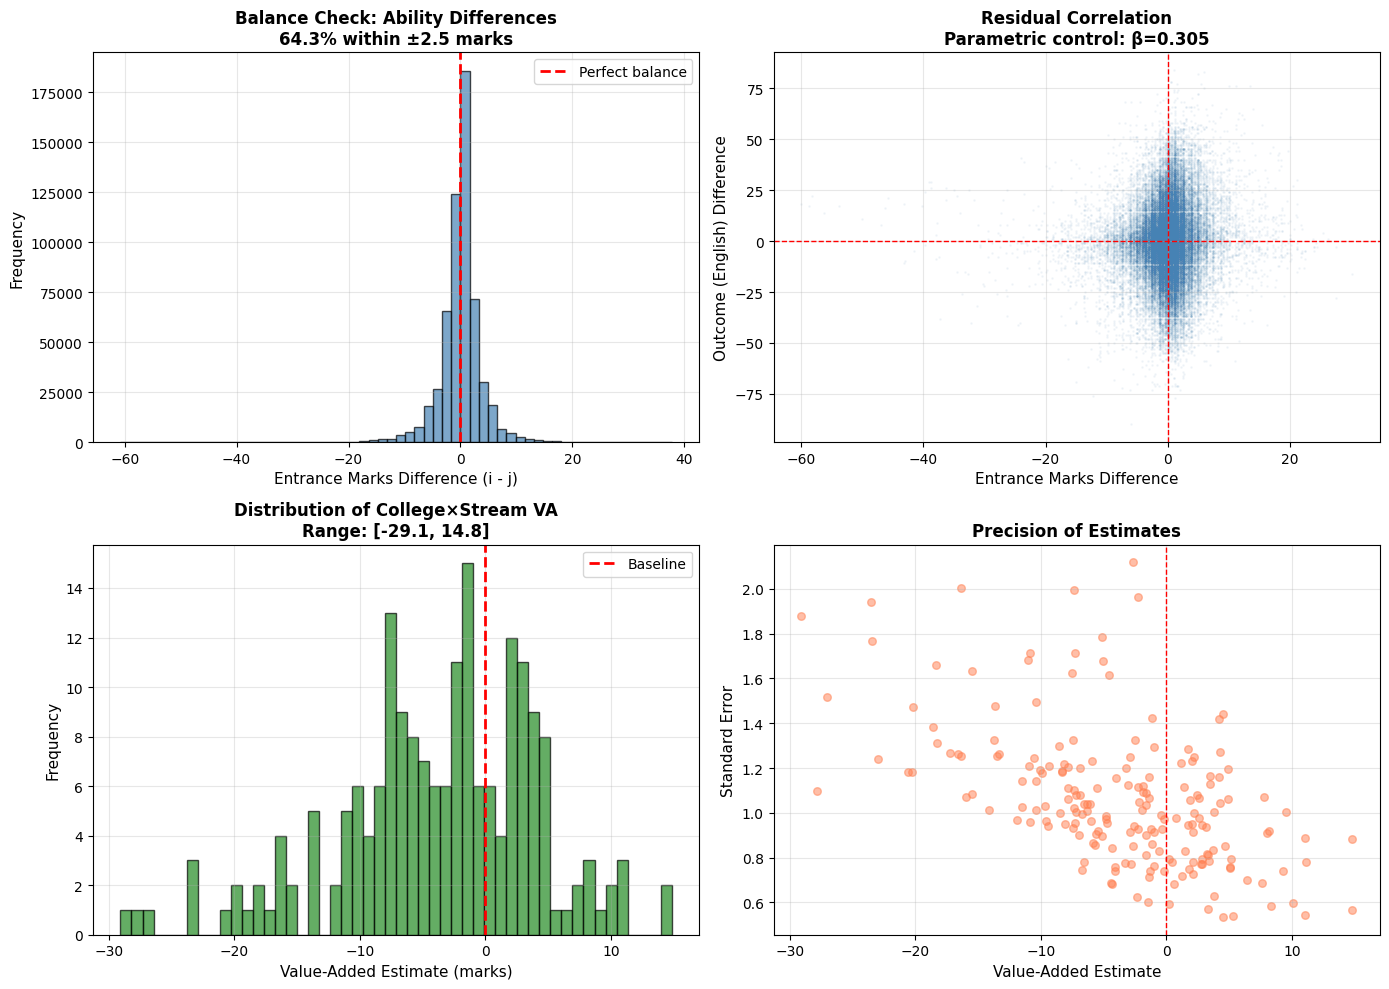

✓ Saved: college_va_diagnostics.png


In [23]:
# ==========================================
# DIAGNOSTIC VISUALIZATIONS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Balance check
axes[0,0].hist(comparison_df["marks_diff"], bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect balance')
axes[0,0].set_xlabel("Entrance Marks Difference (i - j)", fontsize=11)
axes[0,0].set_ylabel("Frequency", fontsize=11)
axes[0,0].set_title(f"Balance Check: Ability Differences\n{pct_2_5:.1f}% within ±2.5 marks", 
                    fontsize=12, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Plot 2: Ability vs Outcome relationship
sample_size = min(50000, len(comparison_df))
sample_idx = np.random.choice(len(comparison_df), sample_size, replace=False)
axes[0,1].scatter(
    comparison_df["marks_diff"].iloc[sample_idx], 
    comparison_df["outcome_diff"].iloc[sample_idx], 
    alpha=0.05, s=1, color='steelblue'
)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_xlabel("Entrance Marks Difference", fontsize=11)
axes[0,1].set_ylabel("Outcome (English) Difference", fontsize=11)
axes[0,1].set_title(f"Residual Correlation\nParametric control: β={marks_diff_coef:.3f}", 
                    fontsize=12, fontweight='bold')
axes[0,1].grid(alpha=0.3)

# Plot 3: Value-added distribution
axes[1,0].hist(va_clean, bins=50, edgecolor='black', alpha=0.7, color='forestgreen')
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[1,0].set_xlabel("Value-Added Estimate (marks)", fontsize=11)
axes[1,0].set_ylabel("Frequency", fontsize=11)
axes[1,0].set_title(f"Distribution of College×Stream VA\nRange: [{va_clean.min():.1f}, {va_clean.max():.1f}]", 
                    fontsize=12, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Plot 4: Precision vs Effect Size
res_clean = results_df[results_df['value_added'].notna()].copy()
axes[1,1].scatter(res_clean['value_added'], res_clean['std_error'], 
                 alpha=0.5, s=30, color='coral')
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_xlabel("Value-Added Estimate", fontsize=11)
axes[1,1].set_ylabel("Standard Error", fontsize=11)
axes[1,1].set_title("Precision of Estimates", fontsize=12, fontweight='bold')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('college_va_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: college_va_diagnostics.png")

In [24]:
# ==========================================
# SAVE RESULTS
# ==========================================

# Prepare metadata
metadata = {
    "specification": {
        "method": "Stratified matching + parametric control",
        "outcome_variable": "englishmarks_12",
        "weights": {
            "marks": float(W_MARKS),
            "stream": float(W_STREAM),
            "preferences": float(W_PREFS),
            "demographics": float(W_DEMO)
        },
        "neighborhood_size": int(K),
        "stratification": "exact_stream_match",
        "parametric_control": "marks_diff"
    },
    "sample": {
        "n_students": int(len(df_feat)),
        "n_comparisons": int(len(comparison_df)),
        "n_college_streams": int(len(results_df))
    },
    "model_fit": {
        "r_squared": float(model.rsquared),
        "adj_r_squared": float(model.rsquared_adj),
        "n_obs": int(model.nobs),
        "marks_diff_coef": float(marks_diff_coef),
        "marks_diff_tstat": float(marks_diff_t),
        "marks_diff_pval": float(marks_diff_p)
    },
    "balance_diagnostics": {
        "mean_marks_diff": float(comparison_df["marks_diff"].mean()),
        "std_marks_diff": float(comparison_df["marks_diff"].std()),
        "pct_within_1.0": float(pct_1_0),
        "pct_within_2.5": float(pct_2_5),
        "pct_within_5.0": float(pct_5_0),
        "pct_within_7.5": float(pct_7_5),
        "pct_within_10.0": float(pct_10_0)
    },
    "value_added_summary": {
        "mean": float(va_clean.mean()),
        "std": float(va_clean.std()),
        "min": float(va_clean.min()),
        "max": float(va_clean.max()),
        "mean_abs": float(va_clean.abs().mean()),
        "n_sig_positive": int(n_sig_pos),
        "n_sig_negative": int(n_sig_neg)
    },
    "baseline_college_stream": baseline_college_stream,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Save main results
results_df.to_csv('college_va_estimates.csv', index=False)
print("✓ Saved: college_va_estimates.csv")

# Save metadata
with open('college_va_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Saved: college_va_metadata.json")

# Save comparison dataset (sample for memory)
sample_size = min(50000, len(comparison_df))
comparison_sample = comparison_df.sample(sample_size, random_state=42)
comparison_sample.to_csv('comparison_diagnostics_sample.csv', index=False)
print(f"✓ Saved: comparison_diagnostics_sample.csv ({sample_size:,} rows)")

print("\n" + "="*60)
print("ALL RESULTS SAVED")
print("="*60)

✓ Saved: college_va_estimates.csv
✓ Saved: college_va_metadata.json
✓ Saved: comparison_diagnostics_sample.csv (50,000 rows)

ALL RESULTS SAVED


In [25]:
# ==========================================
# GENERATE SUMMARY REPORT
# ==========================================

summary_report = f"""
{'='*80}
COLLEGE VALUE-ADDED ESTIMATION - FINAL REPORT
{'='*80}
Generated: {metadata['timestamp']}

METHODOLOGY
{'─'*80}
Identification Strategy:
  - Selection-on-observables framework with rich pre-college controls
  - Stratified matching within stream (avoid comparing MPC to BPC students)
  - Parametric control for residual ability differences
  - Weighted by cosine similarity in high-dimensional feature space

Feature Weighting:
  - Entrance marks (ability):  {W_MARKS} ({W_MARKS/total_weight*100:.1f}%)
  - Stream:                    {W_STREAM} ({W_STREAM/total_weight*100:.1f}%)
  - Preferences:               {W_PREFS} ({W_PREFS/total_weight*100:.1f}%)
  - Demographics:              {W_DEMO} ({W_DEMO/total_weight*100:.1f}%)

Neighborhood size: {K} most similar students per student

SAMPLE
{'─'*80}
Students:                    {metadata['sample']['n_students']:,}
Comparisons:                 {metadata['sample']['n_comparisons']:,}
College×stream combinations: {metadata['sample']['n_college_streams']}

MODEL FIT
{'─'*80}
R-squared:                   {metadata['model_fit']['r_squared']:.4f}
Adjusted R-squared:          {metadata['model_fit']['adj_r_squared']:.4f}
Observations:                {metadata['model_fit']['n_obs']:,}

Parametric Control (marks_diff):
  Coefficient:               {metadata['model_fit']['marks_diff_coef']:.4f}
  t-statistic:               {metadata['model_fit']['marks_diff_tstat']:.2f}
  p-value:                   {metadata['model_fit']['marks_diff_pval']:.4f}
  → Interpretation: 1-mark ability advantage → {metadata['model_fit']['marks_diff_coef']:.3f} mark outcome advantage

BALANCE DIAGNOSTICS
{'─'*80}
Distribution of ability differences (marks_diff):
  Mean:                      {metadata['balance_diagnostics']['mean_marks_diff']:6.2f}
  Std deviation:             {metadata['balance_diagnostics']['std_marks_diff']:6.2f}
  
  % within ±1.0 marks:       {metadata['balance_diagnostics']['pct_within_1.0']:6.1f}%
  % within ±2.5 marks:       {metadata['balance_diagnostics']['pct_within_2.5']:6.1f}%  {'✓' if pct_2_5 > 60 else '⚠'}
  % within ±5.0 marks:       {metadata['balance_diagnostics']['pct_within_5.0']:6.1f}%  {'✓' if pct_5_0 > 80 else '⚠'}
  % within ±7.5 marks:       {metadata['balance_diagnostics']['pct_within_7.5']:6.1f}%
  % within ±10.0 marks:      {metadata['balance_diagnostics']['pct_within_10.0']:6.1f}%

Assessment: {'✓ Excellent balance' if pct_2_5 > 70 else '✓ Good balance' if pct_2_5 > 50 else '⚠ Moderate balance' if pct_2_5 > 30 else '⚠ Weak balance'}

VALUE-ADDED ESTIMATES
{'─'*80}
Range:                       [{metadata['value_added_summary']['min']:.2f}, {metadata['value_added_summary']['max']:.2f}]
Mean:                        {metadata['value_added_summary']['mean']:6.2f}
Std deviation:               {metadata['value_added_summary']['std']:6.2f}
Mean absolute VA:            {metadata['value_added_summary']['mean_abs']:6.2f}

Statistical Significance (p < 0.05):
  Positive VA:               {metadata['value_added_summary']['n_sig_positive']}
  Negative VA:               {metadata['value_added_summary']['n_sig_negative']}

Baseline: {baseline_college_stream} (VA = 0 by construction)

INTERPRETATION
{'─'*80}
1. Value-added estimates reflect the causal effect of attending each college
   on English marks in grade 12, conditional on:
   - Student ability (entrance marks)
   - Stream (academic track)
   - Preferences (information/aspirations)
   - Demographics (gender, caste, region)

2. Estimates are LOCAL - they apply to students in the overlap region
   (those with valid counterfactuals in other colleges)

3. Stratification by stream ensures we compare like-with-like
   (MPC students only compared to other MPC students, etc.)

4. Parametric control absorbs residual bias from imperfect matching

5. Standard errors are clustered at student level to account for
   multiple comparisons per student

CAVEATS
{'─'*80}
- Selection on unobservables cannot be ruled out
- Estimates may not generalize to students far from the margin
- Some colleges may have few comparisons → imprecise estimates
- Peer effects and general equilibrium effects not separately identified

FILES GENERATED
{'─'*80}
- college_va_estimates.csv            (Main results)
- college_va_metadata.json            (Specification details)
- comparison_diagnostics_sample.csv   (Pairwise comparisons)
- college_va_diagnostics.png          (Diagnostic plots)

{'='*80}
END OF REPORT
{'='*80}
"""

# Save report
with open('college_va_summary_report.txt', 'w') as f:
    f.write(summary_report)

print(summary_report)
print("\n✓ Saved: college_va_summary_report.txt")

UnicodeEncodeError: 'charmap' codec can't encode characters in position 260-339: character maps to <undefined>